# Actividad K-NN y Arbol


In [ ]:
import pandas as pd # Para manejar datos en tablas
import numpy as np # Para cálculos numéricos
import matplotlib.pyplot as plt # Para hacer gráficos
import seaborn as sns # Para gráficos más bonitos
from sklearn import datasets # Para cargar datasets
from sklearn.model_selection import train_test_split # Para dividir datos
from sklearn.neighbors import KNeighborsClassifier # Modelo K-NN
from sklearn.preprocessing import StandardScaler # Para normalizar datos
from sklearn.metrics import accuracy_score, confusion_matrix # Para evaluar el modelo
from sklearn.tree import DecisionTreeClassifier, plot_tree # Para trabajar con arboles de decision
from sklearn.metrics import classification_report # Para generar reportes

In [ ]:
# Cargamos el dataset Wine
wine = datasets.load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

## EDA

In [ ]:
# Convertimos en DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(" Análisis Exploratorio ")
print(f"Filas/Columnas: {df.shape} → {df.shape[0]} muestras, {df.shape[1]-1} características")
print(f"Clases: {wine.target_names}\n")

 Análisis Exploratorio 
Filas/Columnas: (178, 14) → 178 muestras, 13 características
Clases: ['class_0' 'class_1' 'class_2']



In [ ]:
# Analizamos Promedio, Mínimos, Máximos, etc.

print("Estadísticas del as 13 caracteristicas:")
print(df.iloc[:, :].describe().round(2))


Estadísticas del as 13 caracteristicas:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12             0.57   
min             0.98        0.34               

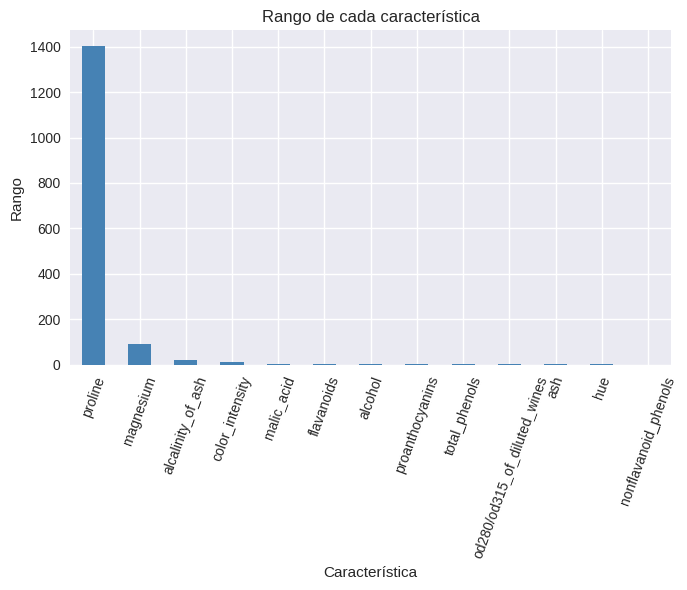

In [ ]:
# Graficamos el rango de los valores de cada Característica.
plt.figure(figsize=(7, 6))
ranges = df.iloc[:, :-1].max() - df.iloc[:, :-1].min()
ranges.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Rango de cada característica')
plt.ylabel('Rango')
plt.xlabel('Característica')
plt.xticks(rotation=70)
plt.tight_layout()
plt.savefig('rangos_caracteristicas.png')
plt.show()

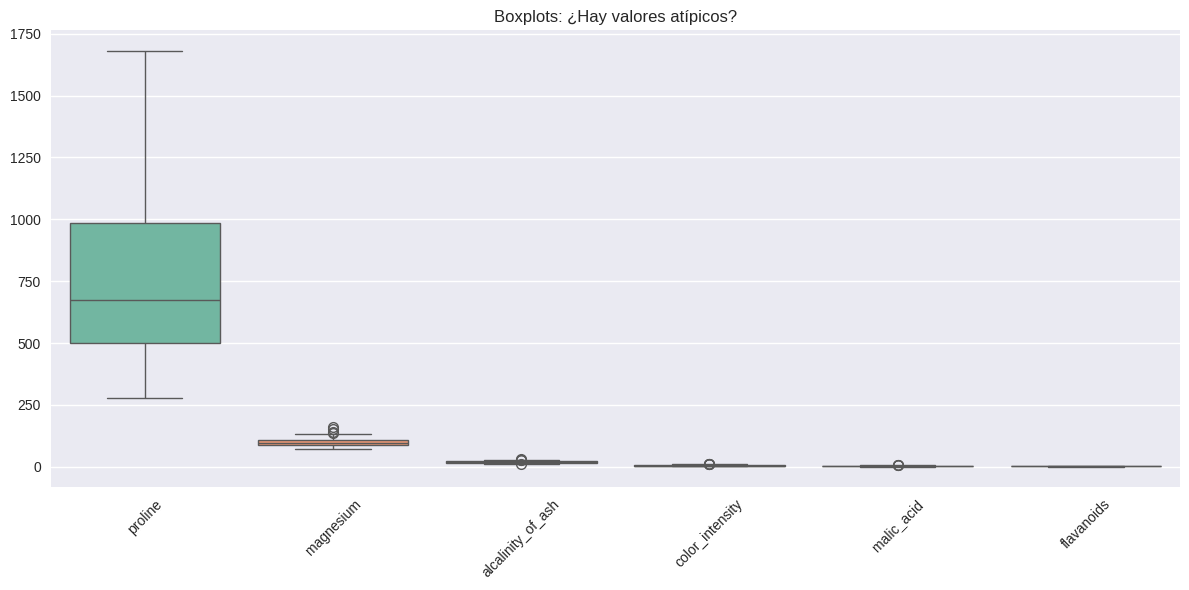

In [ ]:
# Mostramos un Boxplot y Buscamos outliers en los datos.
plt.figure(figsize=(12, 6))
top_features = ranges.nlargest(6).index  # Elegimos las 6 con mayor rango
sns.boxplot(data=df[top_features])
plt.title('Boxplots: ¿Hay valores atípicos?')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplots_outliers.png')
plt.show()


El dataset tiene 178 muestras

3 tipos de clasificacion (Clase_0, Clase_1, Clase_2)

13 caracteristicas quimicas por muestra.

Se observamos valores raros dentro de las estadisticas descriptivas como:

proline: rango 278-1680 (mg/L) , lo cual es muy alto

ash: rango 1,2-3,2 (g/L) lo cual es muy bajo

proline y ash, se normalizaron las escalas ya que como este modelo se basa en distancias, esta diferencia de valores puede hacer que el modelo ignore algunas caracteristicas.

Por lo tanto se aplico StandarScaler() para normalizar las caracteristicas.

Se puede observar como proline tiene un rango muy elevado con respecto al resto de caracteristicas, por lo que se decide realizar un simple tratamiento de los datos para evitar sesgos al momento de usar K-NN.

# Modelo K-NN

## Desarrollo del modelo K-NN

In [ ]:
# Dividimos los datos 80% entrenamiento 20% prueba.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Normalizamos los datos ajustando la escala.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # En esta parte aprende la escala con los datos de entrenamiento
X_test_scaled = scaler.transform(X_test) # Aplica la escala en los datos de prueba

 Una vez los datos estan con la misma escala empezamos a armar el modelo K-NN

In [ ]:
# Creamos el modelo y lo entrenamos.

knn = KNeighborsClassifier(n_neighbors=5) # Los 5 mas cercanos
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
# Predecimos y analizamos la clasificación.

y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Precisión de K-NN : {accuracy:.4f}")


 Precisión de K-NN : 0.9722


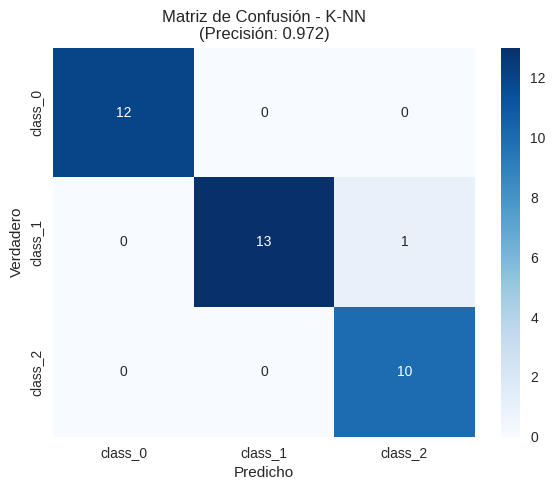


 Reporte de Clasificación - K-NN:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [ ]:
# Usamos la Matriz de confusión que nos muestra cuantas muestras clasifica bien o mal por clase.

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title(f'Matriz de Confusión - K-NN\n(Precisión: {accuracy:.3f})')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('knn_matriz_confusion.png')
plt.show()

# Mostrar reporte de clasificación
print("\n Reporte de Clasificación - K-NN:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

## Ejemplo de Prediccion:

In [ ]:
# Elegimos las 2 características más relevantes:

x_feat, y_feat = 'proline', 'flavanoids'
i, j = feature_names.index(x_feat), feature_names.index(y_feat)

In [ ]:
# Extraemos los datos y los normalizamos.

X_2d = X[:, [i, j]]
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

In [ ]:
# Entrenamos el modelo K-NN.

knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_2d_scaled, y)

KNeighborsClassifier()

In [ ]:
# Tomamos la muestra 10 del dataset como prueba.

idx_muestra = 100
muestra_2d = X_2d_scaled[idx_muestra].reshape(1, -1)
clase_real = y[idx_muestra]

In [ ]:
# Predicción y vecinos más cercanos

clase_predicha = knn_2d.predict(muestra_2d)[0]
distancias, indices_vecinos = knn_2d.kneighbors(muestra_2d, n_neighbors=5)

In [ ]:
# Preparamos los parámetros del grafico

h = 0.02
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

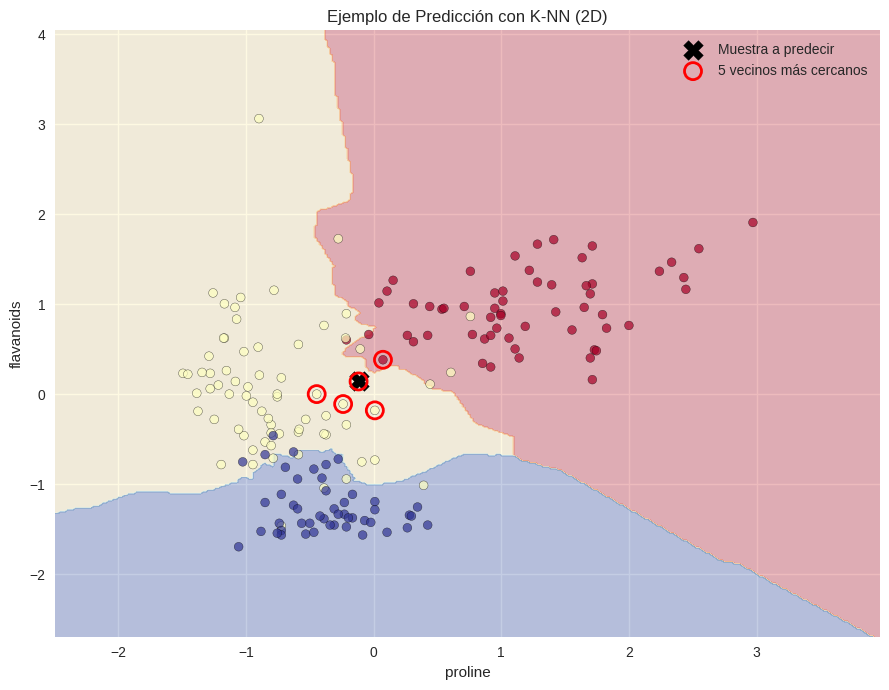


 Ejemplo de predicción:
- Muestra seleccionada: índice 100
- Clase real: class_1
- Clase predicha: class_1
- ¿Correcto?  Sí


In [ ]:
# Graficamos

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

# Agregamos los puntos.

plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1],
            c=y, cmap='RdYlBu', edgecolor='k', s=40, alpha=0.7)

# Resaltamos la muestra que predecimos

plt.scatter(muestra_2d[0, 0], muestra_2d[0, 1],
            c='black', s=200, marker='X', label='Muestra a predecir')

# Vecinos más cercanos
vecinos_x = X_2d_scaled[indices_vecinos[0], 0]
vecinos_y = X_2d_scaled[indices_vecinos[0], 1]
plt.scatter(vecinos_x, vecinos_y,
            facecolors='none', edgecolors='red', s=150, linewidths=2, label='5 vecinos más cercanos')
plt.xlabel(f'{x_feat}')
plt.ylabel(f'{y_feat}')
plt.title('Ejemplo de Predicción con K-NN (2D)')
plt.legend()
plt.tight_layout()
plt.savefig('knn_prediccion_ejemplo.png')
plt.show()

# Mostramos los resultados
print("\n Ejemplo de predicción:")
print(f"- Muestra seleccionada: índice {idx_muestra}")
print(f"- Clase real: {wine.target_names[clase_real]}")
print(f"- Clase predicha: {wine.target_names[clase_predicha]}")
print(f"- ¿Correcto? {' Sí' if clase_real == clase_predicha else ' No'}")

Utilizando estas 2 características graficamos para poder tener una mejor interpretación sobre la predicción del modelo.

# Conclusión K-NN

## Matriz de confusión

El modelo K-NN con k=5 alcanzo una Precisión de 0.9722. Este valor se puede confirmar a la hora de interpretar el valor de accuracy que nos proporciona la matriz.

La matriz de confusión muestra que:

Clase 0= 12 datos, no presento errores por lo que el modelo clasifico perfectamente. Estadísticamente está representado en precisión y recall con un valor en ambos casos del 1,00.

Clase 1= 14 datos, donde fueron clasificadas correctamente 13 con una precisión del 1,00 y 1 incorrecta demostrado con el valor recall 0,93.

Clase 2= 10 datos, donde el valor de precisión 0,91 nos indica que de los 10 datos clasificados 9 eran correctos y el recall nos afirma con un 1,00 que los datos clasificados son reales.

Se puede observar un promedio total de las 36 muestras que varían del 0,97-0,98 lo cual indica que el modelo tiene un rendimiento excelente a la hora de realizar las predicciones.



## Grafico de Frontera

Clase 0 = Rojo

Clase 1 = Amarillo

Clase 2 = Azul

Tomamos como el ejemplo la muestra 10 la cual se clasifico correctamente ya que los vecinos más cercanos pertenecían a la misma clase.


## Conclusión

Este modelo es efectivo, pero es muy importante revisar correctamente el dataset para ver que no interfieran valores atípicos o problemas como en este caso de la escala de en los datos, ya que puede sesgar el análisis realizado. Este modelo es válido para realizar predicciones que clasifiquen si el vino pertenece a la clase 0,1. Pero presenta un error ligero con la clase 2



# Modelo Árbol de de decisión

## Desarrollo del modelo Árbol de decisión:

In [ ]:
# Entrenamos el Árbol de Decisión
tree = DecisionTreeClassifier(max_depth=5, random_state=42) #max_depth=5 son los niveles del árbol
tree.fit(X_train, y_train)  # Usamos los mismos X_train, y_train de K-NN

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
# Predecimos en el conjunto de prueba
y_pred_tree = tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"\n Precisión del Árbol de Decisión: {accuracy_tree:.4f}")


 Precisión del Árbol de Decisión: 0.9444


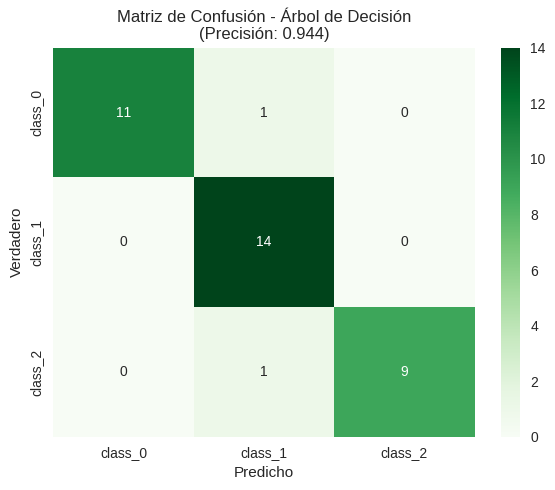


 Reporte de Clasificación - Árbol de Decisión:
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [ ]:
# Matriz de confusión – Árbol de Decisión
plt.figure(figsize=(6, 5))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title(f'Matriz de Confusión - Árbol de Decisión\n(Precisión: {accuracy_tree:.3f})')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('arbol_matriz_confusion.png')
plt.show()

# Mostrar reporte de clasificación
print("\n Reporte de Clasificación - Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree, target_names=wine.target_names))

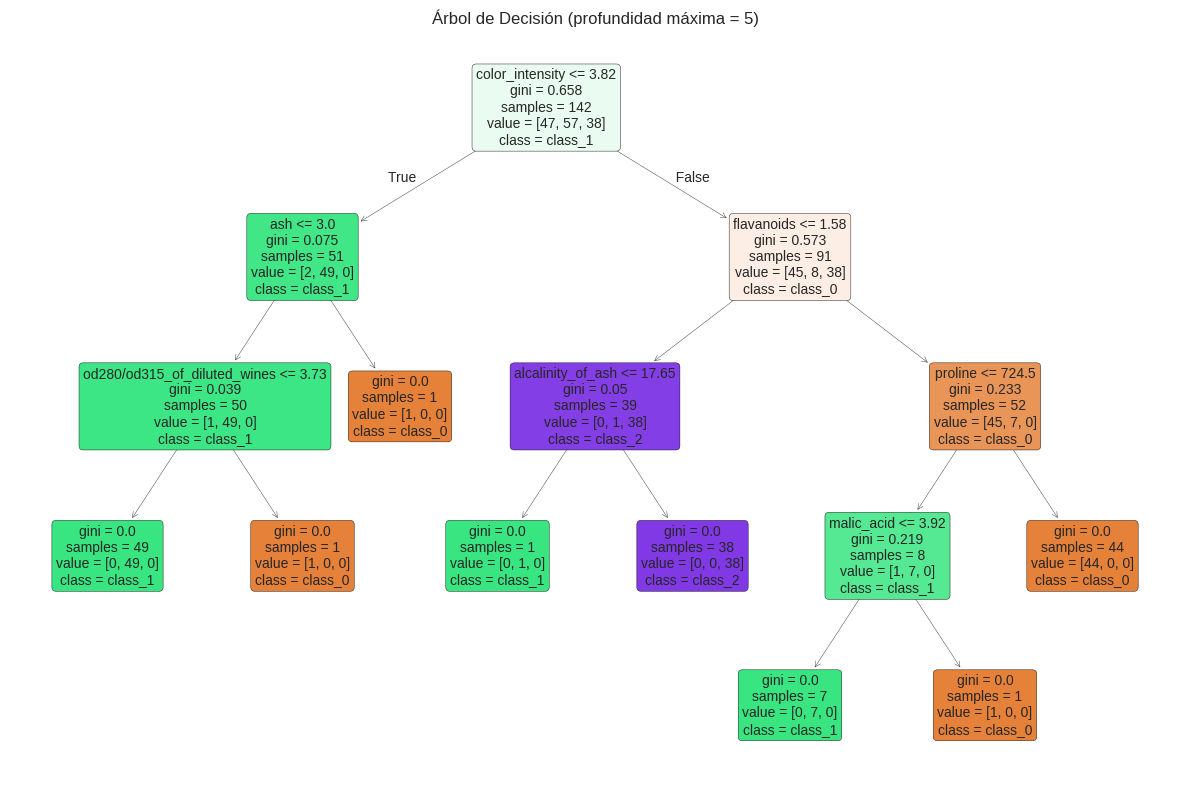

In [ ]:
# Visualizamos el árbol completo
plt.figure(figsize=(12, 8))
plot_tree(tree,
          feature_names=wine.feature_names,
          class_names=wine.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión (profundidad máxima = 5)")
plt.tight_layout()
plt.savefig('arbol_visual.png')
plt.show()

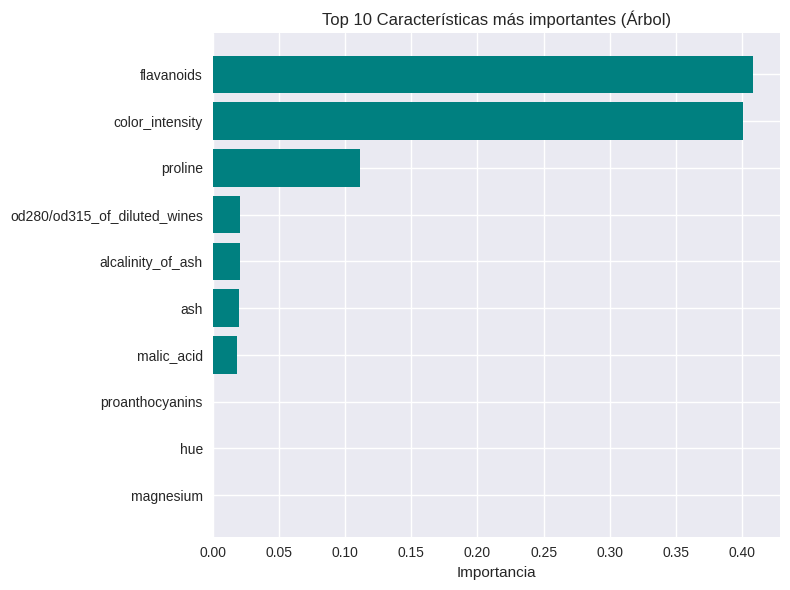

In [ ]:
# Mostramos importancia de características
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.barh(range(10), importances[indices[:10]], color='teal')
plt.yticks(range(10), [wine.feature_names[i] for i in indices[:10]])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Top 10 Características más importantes (Árbol)')
plt.tight_layout()
plt.savefig('arbol_importancia.png')
plt.show()

 Con este grafico podemos observar en que se fija el modelo para distinguir los tipos de vino por ejemplo que compuestos son más discriminados y cuales tienen más valor a la hora de la predicción.

In [ ]:
idx_test = 10
muestra_arbol = X_test[idx_test]
clase_real_arbol = y_test[idx_test]

# Mostramos los valores de la muestra seleccionada
print(f"\n Valores químicos de la muestra seleccionada (índice {idx_test} en X_test):")
for nombre, valor in zip(wine.feature_names, muestra_arbol):
    print(f"  {nombre}: {valor:.2f}")

# Predicción
clase_predicha_arbol = tree.predict([muestra_arbol])[0]

print(f"\n Ejemplo de predicción (Árbol):")
print(f"- Muestra seleccionada: índice {idx_test} del conjunto de prueba")
print(f"- Clase real: {wine.target_names[clase_real_arbol]}")
print(f"- Clase predicha: {wine.target_names[clase_predicha_arbol]}")
print(f"- ¿Correcto? {' Sí' if clase_real_arbol == clase_predicha_arbol else ' No'}")


 Valores químicos de la muestra seleccionada (índice 10 en X_test):
  alcohol: 12.34
  malic_acid: 2.45
  ash: 2.46
  alcalinity_of_ash: 21.00
  magnesium: 98.00
  total_phenols: 2.56
  flavanoids: 2.11
  nonflavanoid_phenols: 0.34
  proanthocyanins: 1.31
  color_intensity: 2.80
  hue: 0.80
  od280/od315_of_diluted_wines: 3.38
  proline: 438.00

 Ejemplo de predicción (Árbol):
- Muestra seleccionada: índice 10 del conjunto de prueba
- Clase real: class_1
- Clase predicha: class_1
- ¿Correcto?  Sí


# Conclusión Árbol de decisión

## Matriz de confusión

El modelo de árbol de decisión alcanzo una Precisión de: 0.9444. Este valor se puede confirmar a la hora de interpretar el valor de accuracy que nos proporciona la matriz.

La matriz de confusión muestra que:

Clase 0= 12 datos. donde 11 fueron correctamente clasificados con una precisión del 1,00 y 1 dato se clasifico de forma errónea, esto se demuestra con el valor recall 0,92.

Clase 1= 14 datos, el valor de precisión 0,88 nos indica que de los 14 datos clasificados 12 eran correctos y el recall nos afirma con un 1,00 que los datos clasificados son reales.

Clase 2= 10 datos, donde 9 fueron correctamente clasificados con una precisión del 1,00 y 1 dato se clasifico de forma errónea, esto se demuestra con el valor recall 0,92

Se puede observar un promedio total de las 36 muestras que varían del 0,94-0,96 lo cual indica que el modelo tiene un rendimiento excelente a la hora de realizar las predicciones.


# Comparación de los modelos.

| Aspecto                       | K-NN                                                                  | Árbol de Decisión                                |
| ----------------------------- | --------------------------------------------------------------------- | ------------------------------------------------ |
| **Preprocesamiento**          | Necesita escalado                                                     | No necesita escalado                             |
| **Complejidad de predicción** | Alta (calcula distancias con todos los puntos)                        | Baja (aplica reglas del árbol)                   |
| **Interpretabilidad**         | Difícil (depende de distancias en espacio multidimensional)           | Alta (fácil de graficar y entender reglas)       |
| Precisión   | Similar a Árbol de Decisión (dependiendo de splits, suele rondar 0.9) | Similar a K-NN (con profundidad 5, también ~0.9) |


Aunque ambos modelos tienen una precisión muy elevada con valores de 0,94 para el modelo de Árbol de decisión y 0,97 para el modelo de K-NN. La elección de uno de ellos depende de las necesidades del problema:

K-NN destaca por un mayor rendimiento en precisión y capacidad para adaptarse en situaciones de decisiones complejas, teniendo en cuenta que los datos estén escalados correctamente. Sin embargo, conlleva un costo computacional más alto al trabajar con conjuntos de datos grandes y la interpretación puede ser limitada.

Árbol de decisión, ofrece una interpretación más clara y visual mediante reglas simples, esto ayuda a la toma de decisiones en situaciones donde es clave tener una explicabilidad de la situación. Además, no requiere normalización de los datos.

En conclusión, si la prioridad es obtener la máxima precisión se recomienda K-NN ya que resulta ligeramente superior en este caso. En caso de necesitar mayor interpretación y simplicidad, se recomienda Árbol de decisión.
